# KuaiRand-Pure 核心指标与业务分析

## 项目定位

本项目使用快手公开脱敏历史数据，分析标准推荐场景下的用户参与、播放质量和内容表现，并对相同日期范围内的标准推荐与随机推荐进行描述性比较。


## 一、业务目标与分析问题

本 notebook 重点回答五类问题：

1. **整体表现**：推荐规模、用户规模、视频规模以及播放和互动表现如何？
2. **时间变化**：每日和不同时段的推荐量、播放质量、互动率是否存在差异？
3. **用户差异**：不同活跃度、创作者身份、注册时长和粉丝规模的用户表现有何不同？
4. **内容差异**：不同视频类型、上传方式、视频时长和横竖屏的视频表现有何不同？
5. **推荐方式比较**：同一时期内，标准推荐和随机推荐的表现存在什么描述性差异？

注意：标准推荐与随机推荐不是用户随机分组的A/B实验，因此只能描述差异，不能声称推荐策略导致了指标提升。


## 二、数据角色与统计粒度

| 数据表 | 一行代表什么                    | 在项目中的角色 |
|---|---------------------------------|---|
| log_standard_clean | 一条 **用户—视频** 推荐行为记录 | 核心事实表 |
| user_features_clean | 一名用户                        | 用户维度表 |
| video_features_basic_clean | 一条视频                        | 视频维度表 |
| log_random_clean | 一条随机推荐行为记录            | 同期描述性对照表 |

主分析以标准推荐日志为基础。用户表按 user_id 连接，视频表按 video_id 连接。

用户和视频会在行为表中重复出现，因此连接关系是“行为表多行对应维度表一行”，即多对一连接。


## 三、核心指标字典

| 指标               | 计算口径                                                    | 分母或统计对象 |
|--------------------|-------------------------------------------------------------|---|
| 推荐记录数         | 行数                                                        | 全部推荐行为 |
| 覆盖用户数         | user_id 去重计数                                            | 全部推荐行为 |
| 覆盖视频数         | video_id 去重计数                                           | 全部推荐行为 |
| 有效播放/点击率    | is_click=1 的记录数 / 推荐记录数                            | 全部推荐行为 |
| 长播率             | long_view=1 的记录数 / 推荐记录数                           | 全部推荐行为 |
| 完整播放率         | is_complete_play=1 的记录数 / is_complete_play 非缺失记录数 | 视频时长有效的行为 |
| 点赞率             | is_like=1 的记录数 / 推荐记录数                             | 全部推荐行为 |
| 评论率             | is_comment=1 的记录数 / 推荐记录数                          | 全部推荐行为 |
| 关注率             | is_follow=1 的记录数 / 推荐记录数                           | 全部推荐行为 |
| 转发率             | is_forward=1 的记录数 / 推荐记录数                          | 全部推荐行为 |
| 综合互动率         | 点赞、评论、关注、转发任一发生                              | 全部推荐行为 |
| 播放时长中位数     | play_time_ms 的中位数并换算为秒                             | 全部推荐行为 |
| 播放进度中位数     | play_ratio_raw 的中位数                                     | 视频时长有效的行为 |
| 进度达到100%的比例 | play_ratio_raw 大于等于1                                    | 视频时长有效的行为 |

完整播放、长播和点击不是严格逐级包含关系，所以本项目把它们作为独立的播放质量指标，不强行绘制成严格漏斗。


# 第一部分：读取固定的清洗数据

## 1. 设置路径并按需读取字段

后续分析统一从 data/processed 读取Parquet文件，不依赖清洗notebook中的内存变量。

为了降低百万级数据的内存占用，行为表只读取核心分析需要的字段；用户表和视频表也只读取有明确业务意义的维度字段。


In [1]:
from pathlib import Path

import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    """从当前目录向上定位作品集根目录。"""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "Python").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("未找到项目根目录，请从 KuaiRand_Pure 目录或其子目录运行。")


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MYSQL_IMPORT_DIR = PROJECT_ROOT / "data" / "mysql_import"
figure_dir = PROJECT_ROOT / "outputs" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

processed_dir = PROCESSED_DIR

behavior_cols = [
    "user_id", "video_id", "date_clean", "hourmin", "is_click",
    "is_like", "is_follow", "is_comment", "is_forward", "long_view",
    "play_time_ms", "duration_ms_clean", "play_ratio_raw",
    "is_complete_play", "log_source"
]

user_cols = [
    "user_id", "user_active_degree", "is_video_author",
    "follow_user_num_range", "fans_user_num_range", "friend_user_num_range",
    "register_days", "register_days_range", "is_live_streamer_clean"
]

video_cols = [
    "video_id", "author_id", "video_type", "upload_type",
    "video_duration_seconds", "server_width", "server_height",
    "music_type_clean", "tag_clean"
]

standard_log = pd.read_parquet(
    processed_dir / "log_standard_clean.parquet", columns=behavior_cols
)
user_dim = pd.read_parquet(
    processed_dir / "user_features_clean.parquet", columns=user_cols
)
video_dim = pd.read_parquet(
    processed_dir / "video_features_basic_clean.parquet", columns=video_cols
)

print("标准推荐行为表：", standard_log.shape)
print("用户维度表：", user_dim.shape)
print("视频维度表：", video_dim.shape)


标准推荐行为表： (1414622, 15)
用户维度表： (27285, 9)
视频维度表： (7583, 9)


## 2. 进入连接前的最后核验

连接前必须确认：

- 标准推荐行为表为1,414,622行；
- user_id 在用户表中唯一；
- video_id 在视频表中唯一；
- 日期和来源分布符合预期。

维度表主键不唯一时，多对一连接可能使主表行数膨胀，因此不能跳过这一步。


In [2]:
assert standard_log.shape[0] == 1414622
assert user_dim["user_id"].is_unique
assert video_dim["video_id"].is_unique
assert standard_log["date_clean"].notna().all()

print("标准推荐日期范围：")
print(
    standard_log["date_clean"].min(),
    "至",
    standard_log["date_clean"].max()
)

print("\n标准推荐来源分布：")
print(
    standard_log["log_source"]
    .value_counts(dropna=False)
)

print("\n连接前核验通过")


标准推荐日期范围：
2022-04-09 00:00:00 至 2022-05-08 00:00:00

标准推荐来源分布：
log_source
standard_0408_0421    1125503
standard_0422_0508     289119
Name: count, dtype: int64

连接前核验通过


# 第二部分：建立标准推荐分析主表

## 1. 连接用户维度表

how="left" 表示保留标准推荐行为表的全部记录。

validate="many_to_one" 要求左表可以有多个相同 user_id，但右侧用户表每个 user_id 只能有一行。

indicator="user_merge_status" 会生成连接状态字段，用于检查行为记录是否成功匹配到用户信息。


In [3]:
rows_before_merge = standard_log.shape[0]

analysis_table = standard_log.merge(
    user_dim,
    on="user_id",
    how="left",
    validate="many_to_one",
    indicator="user_merge_status"
    )
# indicator 用于核验用户维度匹配覆盖。

print("连接用户表前行数：", rows_before_merge)
print("连接用户表后行数：", analysis_table.shape[0])

print("\n用户连接状态：")
print(
    analysis_table["user_merge_status"]
    .value_counts(dropna=False)
)

assert analysis_table.shape[0] == rows_before_merge
assert (
    analysis_table["user_merge_status"] == "both"
).all()

print("\n用户维度连接通过")


连接用户表前行数： 1414622
连接用户表后行数： 1414622

用户连接状态：
user_merge_status
both          1414622
left_only           0
right_only          0
Name: count, dtype: int64

用户维度连接通过


## 2. 连接视频维度表

视频维度连接与用户维度连接遵循相同原则。

连接完成后必须继续保持1,414,622行，并且每条行为记录都应匹配到一条视频基础信息。


In [4]:
analysis_table = analysis_table.merge(
    video_dim,
    on="video_id",
    how="left",
    validate="many_to_one",
    indicator="video_merge_status"
)

print("连接视频表后形状：", analysis_table.shape)

print("\n视频连接状态：")
print(
    analysis_table["video_merge_status"]
    .value_counts(dropna=False)
)

assert analysis_table.shape[0] == rows_before_merge
assert (
    analysis_table["video_merge_status"] == "both"
).all()

analysis_table = analysis_table.drop(
    columns=[
        "user_merge_status",
        "video_merge_status"
    ]
)

print("\n视频维度连接通过")
print("最终连接表形状：", analysis_table.shape)


连接视频表后形状： (1414622, 33)

视频连接状态：
video_merge_status
both          1414622
left_only           0
right_only          0
Name: count, dtype: int64

视频维度连接通过
最终连接表形状： (1414622, 31)


# 第三部分：构造分析字段

## 1. 创建综合互动、小时、分组和横竖屏字段

### 综合互动

点赞、评论、关注和转发可能同时发生，不能把四个字段直接相加后当作“互动用户数”。

本项目将四种互动中任一种发生定义为 has_interaction=1。

### 分组字段

- hour：由 hourmin 的小时部分得到；
- duration_group：按视频秒数划分；
- register_days_group：按注册天数划分；
- screen_orientation：根据视频宽高判断横屏、竖屏或方形。

缺失的视频时长不会被强行分组，而会继续保持缺失。


In [5]:
interaction_cols = [
    "is_like",
    "is_comment",
    "is_follow",
    "is_forward"
]

analysis_table["has_interaction"] = (
    analysis_table[interaction_cols]
    .eq(1)
    .any(axis=1)
    .astype("int8")
)

analysis_table["play_time_seconds"] = (
    analysis_table["play_time_ms"] / 1000
)

analysis_table["hour"] = (
    analysis_table["hourmin"] // 100
).astype("int8")

#按视频秒数，对视频时长分箱
analysis_table["duration_group"] = pd.cut(
    analysis_table["video_duration_seconds"],
    bins=[
        0,
        15,
        30,
        60,
        120,
        float("inf")
    ],
    labels=[
        "0-15秒",
        "15-30秒",
        "30-60秒",
        "60-120秒",
        "120秒以上"
    ],
    right=False,
    include_lowest=True
)

#按用户账号注册天数，对注册时长分箱
analysis_table["register_days_group"] = pd.cut(
    analysis_table["register_days"],
    bins=[
        0,
        180,
        365,
        730,
        1460,
        float("inf")
    ],
    labels=[
        "半年以内",
        "半年-1年",
        "1-2年",
        "2-4年",
        "4年以上"
    ],
    right=False,
    include_lowest=True
)

analysis_table["screen_orientation"] = pd.Series(
    pd.NA,
    index=analysis_table.index,
    dtype="string"
)

valid_resolution = (
    analysis_table["server_width"].notna()
    & analysis_table["server_height"].notna()
)

analysis_table.loc[
    valid_resolution
    & (
        analysis_table["server_width"]
        > analysis_table["server_height"]
    ),
    "screen_orientation"
] = "横屏"

analysis_table.loc[
    valid_resolution
    & (
        analysis_table["server_width"]
        < analysis_table["server_height"]
    ),
    "screen_orientation"
] = "竖屏"

analysis_table.loc[
    valid_resolution
    & (
        analysis_table["server_width"]
        == analysis_table["server_height"]
    ),
    "screen_orientation"
] = "方形"


## 2. 验证衍生字段

衍生字段创建后要检查取值范围和缺失数量。

hour 应在0至23之间；has_interaction 应只包含0和1；视频时长缺失的记录会使 duration_group 保持缺失，这是符合预期的。


In [6]:
print("分析主表形状：", analysis_table.shape)

print("\n综合互动分布：")
print(
    analysis_table["has_interaction"]
    .value_counts(dropna=False)
)

print("\n小时范围：")
print(
    analysis_table["hour"].min(),
    "至",
    analysis_table["hour"].max()
)

print("\n视频时长分组：")
print(
    analysis_table["duration_group"]
    .value_counts(
        dropna=False,
        sort=False    #默认 sort=True：按数量从高到低降序排序；sort=False：不按照频次排序，保持分组原本的先后顺序
    )
)

print("\n注册时长分组：")
print(
    analysis_table["register_days_group"]
    .value_counts(
        dropna=False,
        sort=False
    )
)

print("\n横竖屏分布：")
print(
    analysis_table["screen_orientation"]
    .value_counts(dropna=False)
)

assert set(
    analysis_table["has_interaction"]
    .dropna()
    .unique()       #.unique()获取去重后的值数组    .nunique()获取唯一值个数（即.unique().sum())
).issubset({0, 1})

assert analysis_table["hour"].between(0, 23).all()

print("\n衍生字段验证通过")


分析主表形状： (1414622, 37)

综合互动分布：
has_interaction
0    1383177
1      31445
Name: count, dtype: int64

小时范围：
0 至 23

视频时长分组：
duration_group
0-15秒      173600
15-30秒     200686
30-60秒     213006
60-120秒    373554
120秒以上     424916
NaN         28860
Name: count, dtype: int64

注册时长分组：
register_days_group
半年以内      87732
半年-1年     95982
1-2年     179785
2-4年     492794
4年以上     558329
Name: count, dtype: int64

横竖屏分布：
screen_orientation
竖屏    1074500
横屏     318581
方形      21541
Name: count, dtype: int64[pyarrow]

衍生字段验证通过


# 第四部分：整体核心指标

## 1. 规模指标

规模指标描述样本覆盖范围，不用于评价推荐质量。

推荐记录数、去重用户数和去重视频数应分别理解，不能把同一用户的多次推荐误认为多个用户。


In [7]:
scale_metrics = pd.DataFrame({
    "指标": [
        "推荐记录数",
        "覆盖用户数",
        "覆盖视频数",
        "有效视频时长记录数",
        "视频时长缺失记录数"
    ],
    "数值": [
        analysis_table.shape[0],
        analysis_table["user_id"].nunique(),
        analysis_table["video_id"].nunique(),
        analysis_table["is_complete_play"].notna().sum(),
        analysis_table["is_complete_play"].isna().sum()
    ]
})

scale_metrics


,指标,数值
0,推荐记录数,1414622
1,覆盖用户数,27077
2,覆盖视频数,7551
3,有效视频时长记录数,1385762
4,视频时长缺失记录数,28860


## 2.  播放和互动率指标

二元字段的平均值等于该行为发生的比例。例如，is_like 由0和1组成，其平均值就是点赞率。

完整播放率使用 is_complete_play 的平均值。Pandas计算平均值时会跳过缺失值，所以它的分母是视频时长有效的记录。

综合互动率的分子是至少发生一种互动的记录数，不会重复累计同一条记录中的多种互动。


In [8]:
rate_metric_values = {
    "有效播放/点击率": analysis_table["is_click"].mean(),
    "长播率": analysis_table["long_view"].mean(),
    "完整播放率": analysis_table["is_complete_play"].mean(),
    "点赞率": analysis_table["is_like"].mean(),
    "评论率": analysis_table["is_comment"].mean(),
    "关注率": analysis_table["is_follow"].mean(),
    "转发率": analysis_table["is_forward"].mean(),
    "综合互动率": analysis_table["has_interaction"].mean()
}

rate_metrics = pd.DataFrame({
    "指标": rate_metric_values.keys(),
    "原始小数": rate_metric_values.values()
})

rate_metrics["百分比(%)"] = (
    rate_metrics["原始小数"] * 100
).round(2)

rate_metrics


,指标,原始小数,百分比(%)
0,有效播放/点击率,0.4640,46.4000
1,长播率,0.3356,33.5600
2,完整播放率,0.1543,15.4300
3,点赞率,0.0186,1.8600
4,评论率,0.0026,0.2600
5,关注率,0.0011,0.1100
6,转发率,0.0010,0.1000
7,综合互动率,0.0222,2.2200


### 图1：整体核心行为率

直接使用上方的 `rate_metrics`。横轴是比率，纵轴是指标名称。


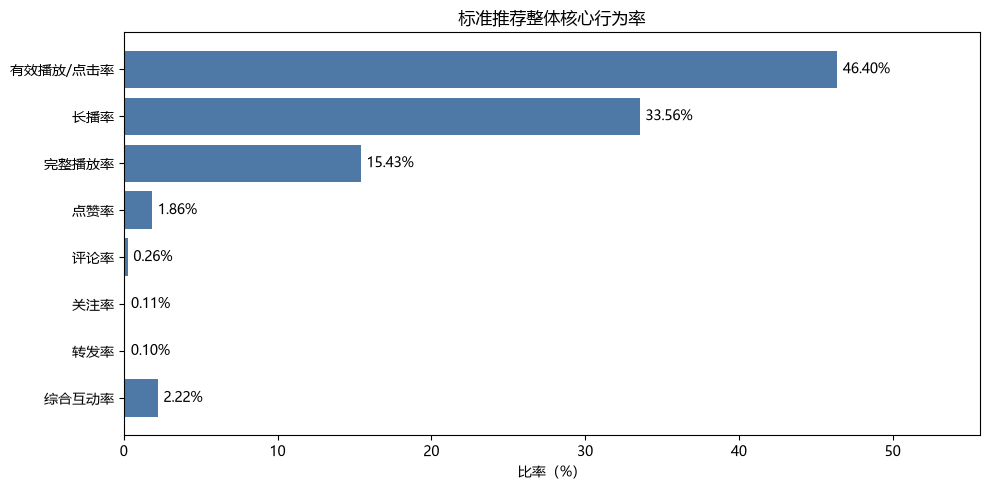

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    rate_metrics["指标"],
    rate_metrics["百分比(%)"],
    color="#4E79A7"
)


ax.bar_label(
    bars,
    labels=[f"{value:.2f}%" for value in rate_metrics["百分比(%)"]],
    padding=4
)


ax.set_title("标准推荐整体核心行为率")
ax.set_xlabel("比率（%）")
ax.invert_yaxis()


ax.set_xlim(0, rate_metrics["百分比(%)"].max() * 1.20)


plt.tight_layout()
fig.savefig(
    figure_dir / "basic_01_overall_rates.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 3. 播放时长和播放进度指标

播放时长和播放进度通常存在长尾分布，因此中位数比单独使用平均数更稳健。

播放进度超过100%可能来自循环播放或重复播放，不直接当作脏数据。本项目不创建强制封顶字段，而是报告播放进度中位数以及达到100%的比例。


In [10]:
valid_play_ratio = (
    analysis_table["play_ratio_raw"]
    .dropna()
)

time_metrics = pd.DataFrame({
    "指标": [
        "播放时长中位数（秒）",
        "播放时长平均数（秒）",
        "播放进度中位数",
        "播放进度平均数",
        "播放进度达到100%的比例（%）"
    ],
    "数值": [
        analysis_table["play_time_seconds"].median(),
        analysis_table["play_time_seconds"].mean(),
        valid_play_ratio.median(),
        valid_play_ratio.mean(),
        (valid_play_ratio >= 1).mean() * 100
    ]
})

time_metrics["数值"] = (
    time_metrics["数值"]
    .round(4)
)

time_metrics


,指标,数值
0,播放时长中位数（秒）,5.0070
1,播放时长平均数（秒）,23.1431
2,播放进度中位数,0.1013
3,播放进度平均数,0.3692
4,播放进度达到100%的比例（%）,15.4330


# 第五部分：时间趋势分析

## 1. 每日表现

每日表用于观察指标随日期的变化，也可以作为后续折线图和Power BI趋势页的基础。

这里的率仍保留为0至1之间的小数，后续可在Power BI中设置为百分比格式，避免重复乘以100。


In [11]:
daily_metrics = (
    analysis_table
    .groupby(
        "date_clean",    #按天拆分所有数据，同一天的数据归为一组
        as_index=False    #date_clean 保持普通字段，不会变成 DataFrame 行索引
    )
    .agg(
        recommendation_records=("user_id", "size"),
        unique_users=("user_id", "nunique"),
        unique_videos=("video_id", "nunique"),
        click_rate=("is_click", "mean"),
        long_view_rate=("long_view", "mean"),
        complete_play_rate=("is_complete_play", "mean"),
        like_rate=("is_like", "mean"),
        comment_rate=("is_comment", "mean"),
        follow_rate=("is_follow", "mean"),
        forward_rate=("is_forward", "mean"),
        interaction_rate=("has_interaction", "mean"),
        median_play_time_seconds=("play_time_seconds", "median")
    )
    .sort_values("date_clean")
    .reset_index(drop=True)
)
#agg()命名聚合(Pandas 新版写法)：新列名 = ("原始列", 聚合方法)
daily_metrics


,date_clean,recommendation_records,unique_users,unique_videos,click_rate,long_view_rate,complete_play_rate,like_rate,comment_rate,follow_rate,forward_rate,interaction_rate,median_play_time_seconds
0,2022-04-09,52481,13561,1933,0.4483,0.3374,0.1717,0.0175,0.0022,0.0007,0.0012,0.0207,4.0050
1,2022-04-10,226258,21011,5258,0.4688,0.3424,0.1521,0.0190,0.0025,0.0008,0.0010,0.0224,4.9550
2,2022-04-11,276058,21110,7090,0.4605,0.3354,0.1555,0.0177,0.0027,0.0010,0.0009,0.0212,4.8430
3,2022-04-12,162517,20073,6380,0.4620,0.3376,0.1542,0.0179,0.0029,0.0009,0.0010,0.0217,5.0030
4,2022-04-13,92052,18163,5691,0.4531,0.3240,0.1475,0.0184,0.0025,0.0011,0.0011,0.0221,4.8595
5,2022-04-14,69194,16910,5189,0.4565,0.3269,0.1512,0.0180,0.0023,0.0013,0.0012,0.0216,4.9590
6,2022-04-15,58326,16035,5019,0.5046,0.3656,0.1738,0.0230,0.0027,0.0013,0.0011,0.0269,6.3855
7,2022-04-16,60592,15520,4906,0.5170,0.3782,0.1798,0.0244,0.0028,0.0012,0.0010,0.0283,6.9050
8,2022-04-17,43615,14545,4603,0.4992,0.3664,0.1702,0.0218,0.0023,0.0014,0.0012,0.0253,6.2610
9,2022-04-18,24202,11025,3953,0.4657,0.3345,0.1556,0.0169,0.0021,0.0014,0.0010,0.0206,5.0280


### 图2：每日推荐量与行为率趋势

直接使用上方的 `daily_metrics`。第一张折线图看每天的推荐记录数，第二张折线图比较点击率、长播率和完整播放率。


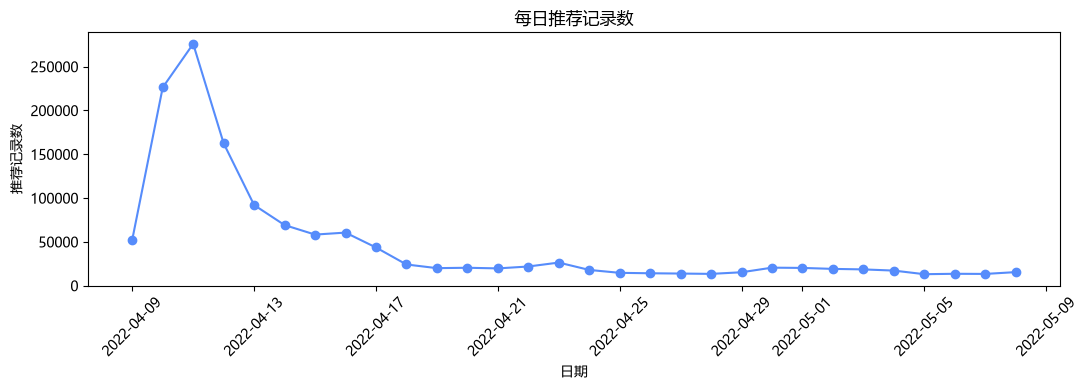

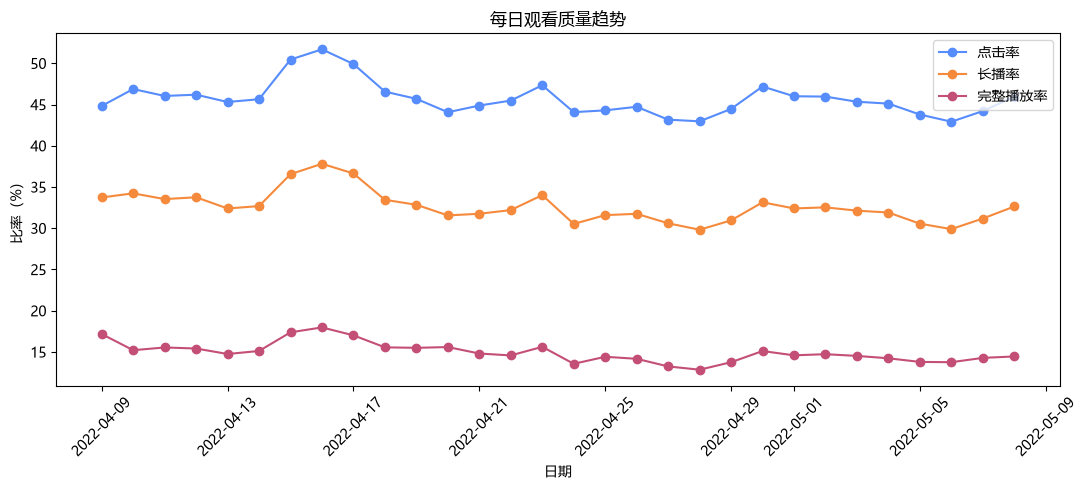

In [12]:
# 每日推荐量
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    daily_metrics["date_clean"],
    daily_metrics["recommendation_records"],
    marker="o"
)

ax.set_title("每日推荐记录数")
ax.set_xlabel("日期")
ax.set_ylabel("推荐记录数")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(
    figure_dir / "basic_02a_daily_volume.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 每日观看质量
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(daily_metrics["date_clean"], daily_metrics["click_rate"] * 100,
        marker="o", label="点击率")
ax.plot(daily_metrics["date_clean"], daily_metrics["long_view_rate"] * 100,
        marker="o", label="长播率")
ax.plot(daily_metrics["date_clean"], daily_metrics["complete_play_rate"] * 100,
        marker="o", label="完整播放率")

ax.set_title("每日观看质量趋势")
ax.set_xlabel("日期")
ax.set_ylabel("比率（%）")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
fig.savefig(
    figure_dir / "basic_02b_daily_rates.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 2. 小时表现

hourly_metrics 用于分析一天中不同时段的推荐量和行为表现。

推荐记录数较少的时段可能出现比例波动，因此解释小时指标时要同时观察样本量，不能只看最高比例。


In [13]:
hourly_metrics = (
    analysis_table
    .groupby(
        "hour",
        as_index=False   #hour保持普通字段，不会变成 DataFrame 行索引
    )
    .agg(
        recommendation_records=("user_id", "size"),
        unique_users=("user_id", "nunique"),
        unique_videos=("video_id", "nunique"),
        click_rate=("is_click", "mean"),
        long_view_rate=("long_view", "mean"),
        complete_play_rate=("is_complete_play", "mean"),
        interaction_rate=("has_interaction", "mean"),
        median_play_time_seconds=("play_time_seconds", "median")
    )
    .sort_values("hour")
    .reset_index(drop=True)
)

hourly_metrics


,hour,recommendation_records,unique_users,unique_videos,click_rate,long_view_rate,complete_play_rate,interaction_rate,median_play_time_seconds
0,0,52154,12387,5302,0.4516,0.3267,0.1445,0.0212,4.5840
1,1,30107,8530,4524,0.4660,0.3402,0.1482,0.0228,5.0760
2,2,18961,6032,3901,0.4692,0.3433,0.1501,0.0223,5.1790
3,3,12436,4468,3266,0.4666,0.3398,0.1558,0.0189,5.0855
4,4,9850,3704,2981,0.4681,0.3463,0.1540,0.0165,5.2320
5,5,11842,4445,3348,0.4724,0.3432,0.1537,0.0198,5.3840
6,6,23466,7944,4347,0.4957,0.3646,0.1688,0.0192,6.2520
7,7,39310,11769,5122,0.5023,0.3748,0.1765,0.0236,6.3475
8,8,47885,13994,5367,0.5032,0.3721,0.1712,0.0221,6.4130
9,9,54196,15283,5488,0.4796,0.3491,0.1625,0.0223,5.5160


### 图3：24小时行为率趋势

横轴是0—23时，纵轴是百分比。三条折线使用同一个坐标轴，便于快速比较不同小时的观看质量。


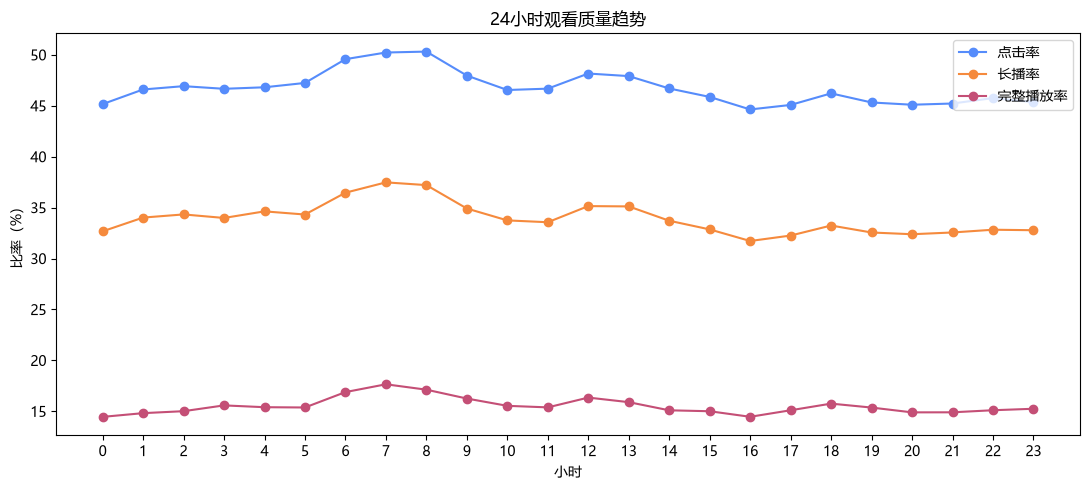

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(hourly_metrics["hour"], hourly_metrics["click_rate"] * 100,
        marker="o", label="点击率")
ax.plot(hourly_metrics["hour"], hourly_metrics["long_view_rate"] * 100,
        marker="o", label="长播率")
ax.plot(hourly_metrics["hour"], hourly_metrics["complete_play_rate"] * 100,
        marker="o", label="完整播放率")

ax.set_title("24小时观看质量趋势")
ax.set_xlabel("小时")
ax.set_ylabel("比率（%）")
ax.set_xticks(range(24))
ax.legend()

plt.tight_layout()
fig.savefig(
    figure_dir / "basic_03_hourly_rates.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 第六部分：用户与内容分层

## 1.1 建立通用分层汇总函数

不同用户和内容维度使用相同指标口径，可以写成一个可复用函数。

group_col 是需要分组的字段名。

dropna=False 表示缺失或未知分组也保留在结果中，避免它们被静默丢弃。

当分组列为 category（分类类型）时：
- `observed=True`：**只对数据里真实存在过的分组做统计**，不存在的分类直接忽略
- `observed=False`：会把分类所有枚举值全部生成分组，哪怕该类别一条数据都没有

输出中的各类rate字段乘以100，仅用于表格阅读；底层分析主表仍保留0至1的小数。


In [15]:
def build_segment_summary(
    data,
    group_col
):
    summary = (
        data
        .groupby(
            group_col,
            dropna=False,
            observed=True
        )
        .agg(
            recommendation_records=("user_id", "size"),
            unique_users=("user_id", "nunique"),
            unique_videos=("video_id", "nunique"),
            click_rate=("is_click", "mean"),
            long_view_rate=("long_view", "mean"),
            complete_play_rate=("is_complete_play", "mean"),
            interaction_rate=("has_interaction", "mean"),
            median_play_time_seconds=("play_time_seconds", "median")
        )
        .reset_index()
    )

    rate_cols = [
        "click_rate",
        "long_view_rate",
        "complete_play_rate",
        "interaction_rate"
    ]

    summary[rate_cols] = (
        summary[rate_cols] * 100
    ).round(2)

    return (
        summary
        .sort_values(
            "recommendation_records",
            ascending=False
        )
        .reset_index(drop=True)
    )


## 2.1 用户活跃度分层

比较不同 user_active_degree 用户的规模、播放质量和互动表现。

结果应同时观察推荐量、用户数和行为率。某组指标较高只表示样本中的相关性，不能直接解释为活跃度导致了行为提升。


In [16]:
user_active_summary = build_segment_summary(
    analysis_table,
    "user_active_degree"
)

user_active_summary


,user_active_degree,recommendation_records,unique_users,unique_videos,click_rate,long_view_rate,complete_play_rate,interaction_rate,median_play_time_seconds
0,full_active,1058721,17871,7529,44.5600,31.9800,14.6400,1.9100,4.4930
1,high_active,227766,6089,6950,51.4700,38.0100,17.9300,3.0100,6.8415
2,middle_active,84235,2107,5354,54.3200,39.9700,18.0000,3.8400,7.9250
3,2_14_day_new,32573,628,4769,47.5700,34.7200,16.0300,2.1200,5.4510
4,low_active,6792,285,2034,57.5800,43.0100,19.6600,4.4000,9.5650
5,single_low_active,2921,66,1496,51.1800,38.9900,17.9600,2.9800,7.2710
6,30day_retention,742,14,558,47.3000,32.4800,14.0800,2.4300,5.3235
7,day_new,626,11,505,50.6400,37.3800,16.7200,2.2400,6.1770
8,UNKNOWN,246,6,238,27.6400,15.4500,7.0800,0.4100,2.0415


### 图4：用户活跃度与三类代表性指标

本图同时比较三类互补指标：

- **点击率**：衡量用户是否愿意开始播放；
- **完整播放率**：衡量用户是否观看完整；
- **综合互动率**：衡量是否发生点赞、评论、关注或转发。

三个指标的量级不同，因此分别放在三个并列的横向柱状图中，避免小指标被大指标压缩。三幅子图使用相同的用户活跃度顺序，方便横向比较。


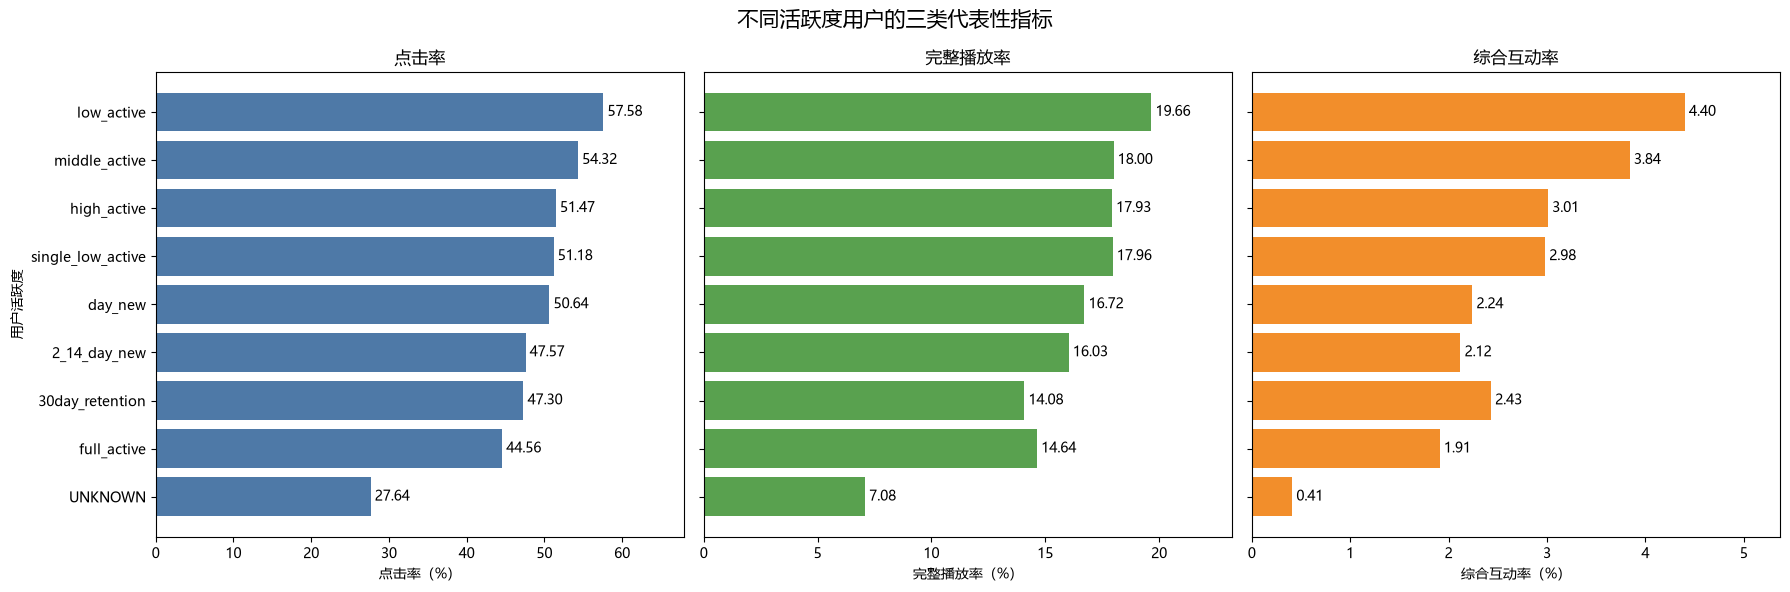

In [17]:
# 三幅图共用同一套用户活跃度顺序。
# 固定坐标轴 y轴顺序
user_active_plot = user_active_summary.sort_values("click_rate")
user_labels = user_active_plot["user_active_degree"].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

click_bars = axes[0].barh(
    user_labels,
    user_active_plot["click_rate"],
    color="#4E79A7"
)
axes[0].bar_label(click_bars, fmt="%.2f", padding=3)
axes[0].set_title("点击率")
axes[0].set_xlabel("点击率（%）")
axes[0].set_ylabel("用户活跃度")
axes[0].set_xlim(0, user_active_plot["click_rate"].max() * 1.18)

complete_bars = axes[1].barh(
    user_labels,
    user_active_plot["complete_play_rate"],
    color="#59A14F"
)

axes[1].bar_label(complete_bars, fmt="%.2f", padding=3)
axes[1].set_title("完整播放率")
axes[1].set_xlabel("完整播放率（%）")
axes[1].set_xlim(0, user_active_plot["complete_play_rate"].max() * 1.18)

interaction_bars = axes[2].barh(
    user_labels,
    user_active_plot["interaction_rate"],
    color="#F28E2B"
)
axes[2].bar_label(interaction_bars, fmt="%.2f", padding=3)
axes[2].set_title("综合互动率")
axes[2].set_xlabel("综合互动率（%）")
axes[2].set_xlim(0, user_active_plot["interaction_rate"].max() * 1.22)

fig.suptitle("不同活跃度用户的三类代表性指标", fontsize=15)
plt.tight_layout()
plt.savefig(
        figure_dir /"basic_04_user_active_rate.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()


## 2.2 其他用户分层

以下三张表分别分析：

- 是否为视频创作者；
- 注册时长分组；
- 粉丝规模分组。

直播用户字段缺失比例较高，因此不作为第一版核心用户分层；如后续使用，必须保留未知组并披露缺失比例。


In [18]:
video_author_summary = build_segment_summary(
    analysis_table,
    "is_video_author"
)

register_days_summary = build_segment_summary(
    analysis_table,
    "register_days_group"
)

fans_range_summary = build_segment_summary(
    analysis_table,
    "fans_user_num_range"
)

print("是否为视频创作者：")
display(video_author_summary)

print("\n注册时长分组：")
display(register_days_summary)

print("\n粉丝规模分组：")
fans_range_summary


是否为视频创作者：


,is_video_author,recommendation_records,unique_users,unique_videos,click_rate,long_view_rate,complete_play_rate,interaction_rate,median_play_time_seconds
0,1,1201965,22145,7537,46.0500,33.2700,15.4300,2.3200,4.8620
1,0,212657,4932,6985,48.3600,35.1600,15.4700,1.6600,5.9050



注册时长分组：


,register_days_group,recommendation_records,unique_users,unique_videos,click_rate,long_view_rate,complete_play_rate,interaction_rate,median_play_time_seconds
0,4年以上,558329,10365,7380,43.7900,31.5100,14.4200,1.6100,4.2540
1,2-4年,492794,9565,7404,45.9500,33.0400,15.2300,2.2800,4.9190
2,1-2年,179785,3448,6884,49.6700,36.2100,16.8300,2.8900,6.1070
3,半年-1年,95982,1767,6207,52.3300,38.4400,17.6100,3.5400,7.1195
4,半年以内,87732,1932,6092,52.3400,38.7700,17.7800,3.0200,7.1850



粉丝规模分组：


,fans_user_num_range,recommendation_records,unique_users,unique_videos,click_rate,long_view_rate,complete_play_rate,interaction_rate,median_play_time_seconds
0,"[10,100)",534763,10387,7408,47.2500,34.2900,15.5500,2.1300,5.4020
1,"[100,1k)",496413,8631,7342,44.1300,31.6200,14.8900,2.5000,4.1580
2,"[1,10)",243185,5262,7121,49.6900,36.4900,16.4200,1.8800,6.3440
3,"[1k,5k)",79285,1447,5720,43.2800,30.5200,14.8900,2.8000,3.7770
4,0,51164,1139,5549,49.1200,35.8700,15.4800,1.1900,6.1165
5,"[5k,1w)",4914,112,2159,43.8500,31.0700,15.0900,2.1800,4.0725
6,"[1w,10w)",4321,85,1904,44.5300,31.5000,15.6300,2.1100,4.4930
7,"[10w,100w)",535,12,433,45.4200,34.5800,19.0100,9.3500,3.9640
8,"[100w,1000w)",42,2,41,57.1400,52.3800,28.5700,14.2900,20.7190


### 图5：注册时长与观看质量

先按照“半年以内 → 4年以上”的业务顺序排列，再用三条基础折线比较点击率、长播率和完整播放率。


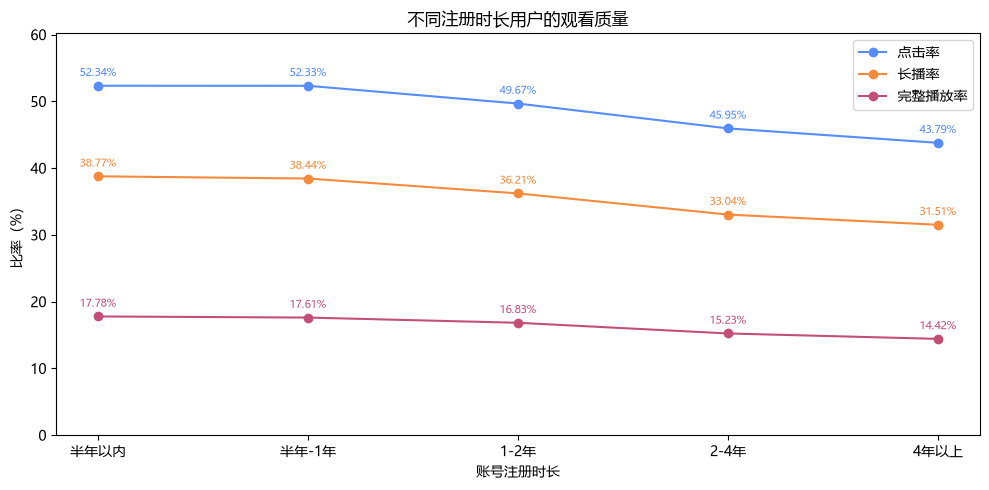

In [19]:
register_order = ["半年以内", "半年-1年", "1-2年", "2-4年", "4年以上"]

register_plot = (
    register_days_summary
    .set_index("register_days_group")
    .reindex(register_order)
    .reset_index()
)
# 手动指定业务顺序，避免字符串字典序打乱时间先后。

fig, ax = plt.subplots(figsize=(10, 5))

click_line, = ax.plot(
    register_plot["register_days_group"].astype(str),
    register_plot["click_rate"],
    marker="o",
    label="点击率"
)
long_line, = ax.plot(
    register_plot["register_days_group"].astype(str),
    register_plot["long_view_rate"],
    marker="o",
    label="长播率"
)
complete_line, = ax.plot(
    register_plot["register_days_group"].astype(str),
    register_plot["complete_play_rate"],
    marker="o",
    label="完整播放率"
)



for line in [click_line, long_line, complete_line]:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.annotate(
            f"{y:.2f}%",
            (x, y),
            textcoords="offset points",
            xytext=(0, 7),
            ha="center",
            fontsize=8,
            color=line.get_color()
        )

ax.set_title("不同注册时长用户的观看质量")
ax.set_xlabel("账号注册时长")
ax.set_ylabel("比率（%）")
ax.legend()
ax.set_ylim(0, register_plot[["click_rate", "long_view_rate", "complete_play_rate"]].max().max() * 1.15)

plt.tight_layout()
fig.savefig(
    figure_dir / "basic_05_register_days_rates.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 3.1 内容特征分层

以下表格分别分析视频类型、上传方式、时长分组和横竖屏。

标签字段虽然可以作为匿名类别比较，但标签组合较多且无法解释真实主题，因此第一版不把标签作为核心结论。


In [20]:
video_type_summary = build_segment_summary(
    analysis_table,
    "video_type"
)

upload_type_summary = build_segment_summary(
    analysis_table,
    "upload_type"
)

duration_summary = build_segment_summary(
    analysis_table,
    "duration_group"
)

orientation_summary = build_segment_summary(
    analysis_table,
    "screen_orientation"
)

print("视频类型：")
display(video_type_summary)

print("\n上传方式：")
display(upload_type_summary)

print("\n视频时长分组：")
display(duration_summary)

print("\n横竖屏：")
display(orientation_summary)


视频类型：


,video_type,recommendation_records,unique_users,unique_videos,click_rate,long_view_rate,complete_play_rate,interaction_rate,median_play_time_seconds
0,NORMAL,1396862,27074,7475,46.3600,33.5100,15.5500,2.2200,5.0000
1,AD,15542,8974,75,48.4900,36.2600,5.9800,2.3400,5.3790
2,UNKNOWN,2218,2204,1,54.5100,43.8700,6.7600,0.8100,8.0940



上传方式：


,upload_type,recommendation_records,unique_users,unique_videos,click_rate,long_view_rate,complete_play_rate,interaction_rate,median_play_time_seconds
0,LongImport,613289,26576,2915,47.6300,34.6800,13.5500,2.1200,5.2350
1,Web,422514,26157,2400,50.1900,36.9900,14.5500,2.0100,6.3740
2,ShortImport,201495,23742,916,41.2400,29.5500,28.2800,3.0700,4.2400
3,Kmovie,118677,22660,877,43.0500,30.4000,9.2100,1.7300,3.8410
4,LongPicture,21550,9932,143,23.1700,7.4700,<NA>,4.3900,1.9305
5,UNKNOWN,17454,9830,79,44.5100,32.8900,5.8200,2.1700,4.3195
6,ShortCamera,7421,5379,43,24.6600,9.7000,9.0600,1.8700,2.3050
7,ShareFromOtherApp,4241,3019,29,34.0000,23.9800,9.4600,1.3700,2.1790
8,PictureSet,4039,2978,71,17.8000,6.4900,<NA>,2.3800,1.5160
9,LongCamera,3753,3056,64,32.7500,20.7300,5.4600,1.5700,2.0400



视频时长分组：


,duration_group,recommendation_records,unique_users,unique_videos,click_rate,long_view_rate,complete_play_rate,interaction_rate,median_play_time_seconds
0,120秒以上,424916,26335,2414,45.8100,32.5800,5.7200,1.6400,4.9150
1,60-120秒,373554,25748,2097,49.5400,36.7000,12.3600,1.9300,5.9160
2,30-60秒,213006,24010,1066,48.9100,36.0700,18.2200,2.5900,5.6030
3,15-30秒,200686,24359,963,46.5300,32.0700,25.7400,2.5300,5.0275
4,0-15秒,173600,23384,774,41.8000,32.1900,30.4900,3.1600,4.4940
5,NaN,28860,11222,237,22.5600,7.2500,<NA>,4.0700,1.8450



横竖屏：


,screen_orientation,recommendation_records,unique_users,unique_videos,click_rate,long_view_rate,complete_play_rate,interaction_rate,median_play_time_seconds
0,竖屏,1074500,27003,5628,45.1100,32.6200,16.2700,2.1100,4.6420
1,横屏,318581,24828,1811,51.2400,37.3500,12.6800,2.3700,6.7660
2,方形,21541,10747,112,38.9500,24.0900,14.5900,5.5400,3.5200


### 图6：视频时长与观看质量

按照视频时长的自然顺序排列，比较点击率、长播率和完整播放率。


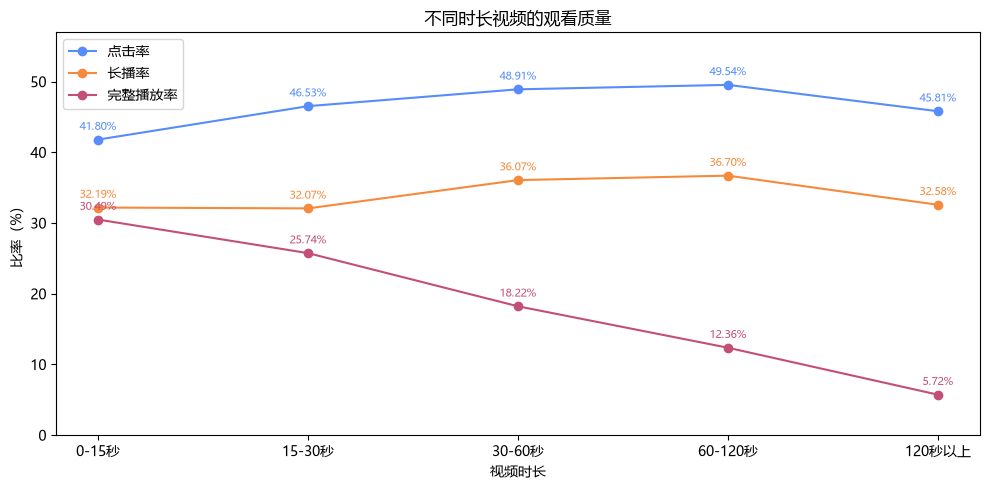

In [21]:
duration_order = ["0-15秒", "15-30秒", "30-60秒", "60-120秒", "120秒以上"]

duration_plot = (
    duration_summary
    .set_index("duration_group")
    .reindex(duration_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

click_line, = ax.plot(
    duration_plot["duration_group"].astype(str),
    duration_plot["click_rate"],
    marker="o",
    label="点击率"
)
long_line, = ax.plot(
    duration_plot["duration_group"].astype(str),
    duration_plot["long_view_rate"],
    marker="o",
    label="长播率"
)
complete_line, = ax.plot(
    duration_plot["duration_group"].astype(str),
    duration_plot["complete_play_rate"],
    marker="o",
    label="完整播放率"
)

for line in [click_line, long_line, complete_line]:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.annotate(
            f"{y:.2f}%",
            (x, y),
            textcoords="offset points",
            xytext=(0, 7),
            ha="center",
            fontsize=8,
            color=line.get_color()
        )

ax.set_title("不同时长视频的观看质量")
ax.set_xlabel("视频时长")
ax.set_ylabel("比率（%）")
ax.legend()
ax.set_ylim(0, duration_plot[["click_rate", "long_view_rate", "complete_play_rate"]].max().max() * 1.15)

plt.tight_layout()
fig.savefig(
    figure_dir / "basic_06_duration_rates.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 第七部分：标准推荐与随机推荐的同期比较

## 1. 构造可比样本

随机推荐日志的日期范围是2022-04-22至2022-05-08，所以标准推荐也只保留相同来源区间。

比较时使用比例和中位数，不直接比较推荐记录总量，因为两张表的样本量和采样方式不同。

随机推荐不连接用户和视频维度表，本部分只使用两张日志都具备的行为字段。


In [22]:
random_log = pd.read_parquet(
    processed_dir / "log_random_clean.parquet",
    columns=behavior_cols
)

standard_same_period = (
    standard_log[
        standard_log["log_source"]
        == "standard_0422_0508"
    ]
    .copy()
)

random_same_period = random_log.copy()

for table in [
    standard_same_period,
    random_same_period
]:
    table["has_interaction"] = (
        table[interaction_cols]
        .eq(1)
        .any(axis=1)
        .astype("int8")
    )

    table["play_time_seconds"] = (
        table["play_time_ms"] / 1000
    )

print("同期标准推荐：", standard_same_period.shape)
print("同期随机推荐：", random_same_period.shape)

print("\n同期标准推荐日期：")
print(
    standard_same_period["date_clean"].min(),
    "至",
    standard_same_period["date_clean"].max()
)

print("\n同期随机推荐日期：")
print(
    random_same_period["date_clean"].min(),
    "至",
    random_same_period["date_clean"].max()
)

assert standard_same_period.shape[0] == 289119
assert random_same_period.shape[0] == 1186049

assert (
    standard_same_period["date_clean"].min()
    == random_same_period["date_clean"].min()
)

assert (
    standard_same_period["date_clean"].max()
    == random_same_period["date_clean"].max()
)

print("\n同期样本验证通过")


同期标准推荐： (289119, 17)
同期随机推荐： (1186049, 17)

同期标准推荐日期：
2022-04-22 00:00:00 至 2022-05-08 00:00:00

同期随机推荐日期：
2022-04-22 00:00:00 至 2022-05-08 00:00:00

同期样本验证通过


## 2. 比较播放和互动率

结果中的“差值”使用百分点。

例如标准推荐率为20%、随机推荐率为18%，差值为2个百分点，而不是提升2%。

这些差异仍然只是样本描述，不代表推荐策略的因果效果。


In [23]:
def build_rate_series(data):
    return pd.Series({
        "有效播放/点击率": data["is_click"].mean(),
        "长播率": data["long_view"].mean(),
        "完整播放率": data["is_complete_play"].mean(),
        "点赞率": data["is_like"].mean(),
        "评论率": data["is_comment"].mean(),
        "关注率": data["is_follow"].mean(),
        "转发率": data["is_forward"].mean(),
        "综合互动率": data["has_interaction"].mean()
    })


comparison_rates_raw = pd.DataFrame({
    "标准推荐": build_rate_series(
        standard_same_period
    ),
    "随机推荐": build_rate_series(
        random_same_period
    )
})

comparison_rates = pd.DataFrame({
    "标准推荐(%)": (
        comparison_rates_raw["标准推荐"]
        * 100
    ).round(2),
    "随机推荐(%)": (
        comparison_rates_raw["随机推荐"]
        * 100
    ).round(2)
})

comparison_rates["差值（百分点）"] = (
    comparison_rates["标准推荐(%)"]
    - comparison_rates["随机推荐(%)"]
).round(2)

comparison_rates


,标准推荐(%),随机推荐(%),差值（百分点）
有效播放/点击率,45.1200,17.6200,27.5000
长播率,31.8300,8.5000,23.3300
完整播放率,14.3200,3.3200,11.0000
点赞率,1.7900,0.4800,1.3100
评论率,0.2500,0.0300,0.2200
关注率,0.1300,0.0300,0.1000
转发率,0.0800,0.0300,0.0500
综合互动率,2.1400,0.5600,1.5800


### 图7：标准推荐相对随机推荐的指标差值

直接使用上方已经计算好的“差值（百分点）”。正数表示同期样本中标准推荐的指标高于随机推荐。横向柱状图可以快速看出差异大小。

注意：这仍是描述性比较，不是A/B实验，也不能解释为因果提升。


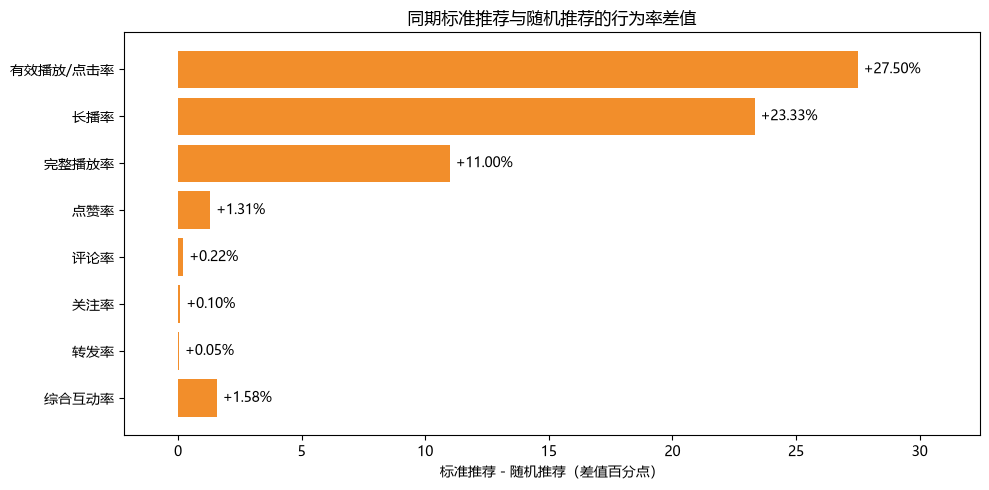

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    comparison_rates.index,
    comparison_rates["差值（百分点）"],
    color="#F28E2B"
)
ax.bar_label(
    bars,
    labels=[f"{value:+.2f}%" for value in comparison_rates["差值（百分点）"]],
    padding=4
)

ax.set_title("同期标准推荐与随机推荐的行为率差值")
ax.set_xlabel("标准推荐 - 随机推荐（差值百分点）")
ax.invert_yaxis()

# 为正负差值及其数值标签预留空间。
gap_min = comparison_rates["差值（百分点）"].min()
gap_max = comparison_rates["差值（百分点）"].max()
gap_range = max(gap_max - gap_min, 1)
ax.set_xlim(min(0, gap_min) - gap_range * 0.08,
            max(0, gap_max) + gap_range * 0.18)

plt.tight_layout()
fig.savefig(
    figure_dir / "basic_07_standard_random_gap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 3. 比较播放时长和播放进度分布

播放时长和播放进度使用中位数，降低极端值影响。

进度达到100%的比例只在 play_ratio_raw 非缺失记录中计算，避免时长未知记录被错误放入分母。


In [25]:
def build_play_distribution(data):
    valid_ratio = (
        data["play_ratio_raw"]
        .dropna()
    )

    return pd.Series({
        "播放时长中位数（秒）":
            data["play_time_seconds"].median(),
        "播放进度中位数":
            valid_ratio.median(),
        "进度达到100%的比例（%）":
            (valid_ratio >= 1).mean() * 100
    })


comparison_distribution = pd.DataFrame({
    "标准推荐": build_play_distribution(
        standard_same_period
    ),
    "随机推荐": build_play_distribution(
        random_same_period
    )
}).round(4)

comparison_distribution["标准-随机"] = (
    comparison_distribution["标准推荐"]
    - comparison_distribution["随机推荐"]
).round(4)

comparison_distribution


,标准推荐,随机推荐,标准-随机
播放时长中位数（秒）,4.8310,2.0910,2.7400
播放进度中位数,0.0955,0.0348,0.0607
进度达到100%的比例（%）,14.3247,3.3187,11.0060


### 图8：标准推荐与随机推荐的播放时长中位数

`comparison_distribution.loc[...]` 从上方结果表取出“播放时长中位数（秒）”这一行。这里只比较同一种单位，避免把秒和百分比强行放在同一纵轴。


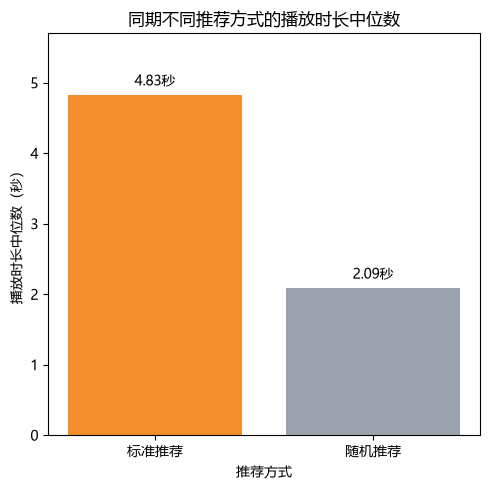

In [26]:
median_play_time = comparison_distribution.loc[
    "播放时长中位数（秒）",
    ["标准推荐", "随机推荐"]
]

# 基础图8只有两根柱子，使用较窄画布即可。
fig, ax = plt.subplots(figsize=(5, 5))

bars = ax.bar(
    median_play_time.index,
    median_play_time.values,
    color=["#F28E2B", "#9CA3AF"]
)
ax.bar_label(
    bars,
    labels=[f"{value:.2f}秒" for value in median_play_time.values],
    padding=4
)

ax.set_title("同期不同推荐方式的播放时长中位数")
ax.set_xlabel("推荐方式")
ax.set_ylabel("播放时长中位数（秒）")
ax.set_ylim(0, median_play_time.max() * 1.18)

plt.tight_layout()
fig.savefig(
    figure_dir / "basic_08_median_play_time.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 第八部分：分析结论

本部分基于前述代码的实际运行结果，从整体、时间、用户、内容和推荐方式五个角度总结。每条结论均按照“数据证据—业务解释—行动建议—限制条件”展开。

## 1. 整体表现

- **数据证据：** 标准推荐日志共包含 1,414,622 条推荐记录，覆盖 27,077 名用户和 7,551 个视频。其中 1,385,762 条记录的视频时长有效，28,860 条记录缺少有效视频时长，缺失比例约为 2.04%。整体有效播放/点击率为 46.40%，长播率为 33.56%，完整播放率为 15.43%，综合互动率为 2.22%；播放时长中位数为 5.007 秒，播放进度中位数仅为 10.13%。
- **业务解释：** 推荐内容获得有效播放的比例接近一半，但从有效播放继续转化为深度观看和互动的空间仍然较大。点击率明显高于完整播放率和综合互动率，说明“用户愿意开始播放”不等于“用户愿意持续观看或互动”，不能只使用点击率评价推荐质量。
- **行动建议：** 将指标分成三层管理：第一层看有效播放/点击率，衡量内容是否吸引用户开始观看；第二层看长播率、完整播放率和播放进度，衡量观看质量；第三层看点赞、评论、关注、转发及综合互动率，衡量深度参与。运营优化时应同时观察三层指标，避免为了提高点击率而牺牲观看质量。
- **限制条件：** 完整播放率和播放进度只使用视频时长有效的记录作为统计对象；缺少时长的 28,860 条记录不能参与这两个指标的计算。

## 2. 时间表现

- **数据证据（日维度）：** 每日推荐量差异很大，4 月 11 日达到 276,058 条，随后明显下降，5 月初多数日期约为 1.3 万至 2.0 万条。4 月 15—17 日的观看指标相对突出，其中 4 月 16 日点击率为 51.70%、长播率为 37.82%、完整播放率为 17.98%、综合互动率为 2.83%，播放时长中位数为 6.905 秒；4 月 27—28 日的点击率、长播率和完整播放率相对较低。
- **数据证据（小时维度）：** 7—8 时的点击率分别为 50.23% 和 50.32%，长播率分别为 37.48% 和 37.21%；7 时完整播放率达到 17.65%。推荐量则在晚间更高，21 时和 22 时分别有 102,161 条和 107,154 条记录，但点击率只有 45.22% 和 45.75%。13 时综合互动率为 2.50%，是各小时中的较高水平。
- **业务解释：** 早晨 7—8 时属于“单位曝光效率较高”的时段，晚间 21—22 时属于“用户规模和推荐量较大”的时段，两者承担的运营目标不同。每日推荐量的剧烈变化也可能来自数据采集范围、抽样方式或流量结构变化，不能直接解释为平台业务量下滑。
- **行动建议：** 将时段策略拆分为“效率时段”和“规模时段”：早晨可测试高质量、强完播导向的内容，晚间可利用较大流量扩大覆盖，同时针对晚间较低的观看效率优化内容匹配。进一步分析时，应按日期、用户活跃度和内容类型交叉验证时段差异。
- **限制条件：** 当前结果是历史行为的描述性统计，且日期推荐量不均衡；在没有流量分配规则和实验信息的情况下，不能把某个日期或小时的较高指标直接归因于发布时间。

## 3. 用户分层

- **数据证据（活跃度）：** full_active 用户贡献 1,058,721 条推荐记录，是主要流量来源，但其点击率、长播率、完整播放率和综合互动率分别为 44.56%、31.98%、14.64% 和 1.91%。low_active 用户的四项指标分别为 57.58%、43.01%、19.66% 和 4.40%，但该组只有 6,792 条记录、285 名用户；middle_active 用户在 84,235 条记录上取得 54.32%的点击率和 3.84%的综合互动率。
- **数据证据（注册时长）：** 注册半年以内用户的点击率、长播率和完整播放率分别为 52.34%、38.77% 和 17.78%，而注册 4 年以上用户分别为 43.79%、31.51% 和 14.42%；两组综合互动率分别为 3.02% 和 1.61%。
- **数据证据（创作者与粉丝规模）：** 非视频创作者的点击率和长播率为 48.36% 和 35.16%，高于视频创作者的 46.05% 和 33.27%；视频创作者的综合互动率为 2.32%，高于非创作者的 1.66%。粉丝数超过 10 万的分组虽有较高指标，但样本只有 535 条或更少，不能作为稳定结论。
- **业务解释：** 高活跃老用户贡献了主要流量，但中低活跃用户和较新注册用户在当前样本中表现出更高的观看效率，可能存在唤醒和新用户培育价值。创作者与非创作者的行为目标可能不同：非创作者更偏向观看，创作者更容易产生互动。
- **行动建议：** 对 full_active 用户重点优化内容新鲜度和深度观看，对 middle_active、low_active 及较新注册用户设计分层承接与留存策略；创作者人群可加强评论、关注等互动型内容推荐，非创作者可优先优化观看体验。正式制定策略前，应设置最小样本量门槛，对小样本人群延长观察周期。
- **限制条件：** 用户分层之间的曝光内容、推荐强度和样本规模并不一致，上述差异只能说明相关关系，不能证明某种用户属性导致了更高的转化率。

## 4. 内容分层

- **数据证据（视频类型与上传方式）：** NORMAL 视频占绝大多数，共 1,396,862 条推荐记录，点击率为 46.36%、完整播放率为 15.55%。AD 视频有 15,542 条记录，点击率和长播率分别为 48.49% 和 36.26%，但完整播放率仅为 5.98%。Web 上传内容的点击率和长播率较高，分别为 50.19% 和 36.99%；ShortImport 内容的完整播放率和综合互动率分别为 28.28% 和 3.07%。
- **数据证据（视频时长）：** 60—120 秒视频的点击率最高，为 49.54%；30—60 秒视频的长播率为 36.07%；0—15 秒视频的完整播放率和综合互动率最高，分别为 30.49% 和 3.16%；120 秒以上视频的完整播放率仅为 5.72%。
- **数据证据（画面方向）：** 横屏视频点击率为 51.24%、长播率为 37.35%，播放时长中位数为 6.766 秒，均高于竖屏；竖屏视频完整播放率为 16.27%，高于横屏的 12.68%；方形视频综合互动率为 5.54%，但只有 21,541 条记录和 112 个视频。
- **业务解释：** 不同内容形态的优势指标不同：中等时长和横屏内容更有利于点击及长时间观看，短视频更容易完整播放和产生互动。AD 视频“点击和长播较高、完整播放较低”的现象可能与视频时长、投放位置或内容结构有关，不能仅根据视频类型判断质量。
- **行动建议：** 采用分目标内容策略：以拉长观看时长为目标时，重点测试 30—120 秒及横屏内容；以提高完播和互动为目标时，重点测试 0—30 秒内容。后续应在相同时长区间内比较视频类型、上传方式和画面方向，减少内容时长造成的混杂影响。
- **限制条件：** 完整播放率天然受到视频长度影响，短视频更容易达到 100%，因此不能单独据此判定短视频质量更高。UNKNOWN和部分上传方式的样本极少，也不宜据此制定普遍策略。

## 5. 标准推荐与随机推荐

- **数据证据：** 在共同的 2022 年 4 月 22 日至 5 月 8 日期间，标准推荐包含 289,119 条记录，随机推荐包含 1,186,049 条记录。标准推荐的点击率、长播率、完整播放率和综合互动率分别为 45.12%、31.83%、14.32% 和 2.14%，分别比随机推荐高 27.50、23.33、11.00 和 1.58 个百分点。标准推荐的播放时长中位数为 4.831 秒，比随机推荐高 2.740 秒；播放进度中位数高 0.0607，进度达到 100%的比例高 11.006 个百分点。
- **描述性解释：** 在这批同期历史样本中，标准推荐在开始播放、深度观看、完整播放和互动方面均与更好的表现相关，说明个性化匹配可能筛选出了更符合用户兴趣的内容。相比单看点击率，多项观看质量指标方向一致，使这一描述性结论更有说服力。
- **行动建议：** 可将随机推荐作为基准组，用于持续监控标准推荐在点击、长播、完整播放和互动等多层指标上的差异；业务汇报中使用“同期样本中标准推荐表现更高”，不要表述为“标准推荐使指标提升”。若要确认推荐策略产生的真实增量，应设计用户级随机分流的 A/B 实验，并统一曝光位置、时间和用户结构。
- **限制条件：** 该比较不是用户随机分组的 A/B 实验，标准推荐与随机推荐的样本量、用户构成、内容构成及曝光机制可能不同，因此只能得出相关性和描述性差异，不能得出因果结论。
